# Defining Differential Equations

This page shows how to express a differential-equation system in `braincell`
using the two protocol pieces introduced in the [overview](overview):
`DiffEqState` and `DiffEqModule`. By the end you will have built a runnable
model from scratch and integrated it with a real solver.

In [1]:
import brainstate
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

import braincell
from braincell import DiffEqState, DiffEqModule

## `DiffEqState`: a variable the solver integrates

`DiffEqState` extends `brainstate.HiddenState` with two extra slots that the
solver reads and writes during a step:

- **`derivative`** — the right-hand side $f(t, y)$ of an ODE $\dot y = f(t, y)$,
  or the *drift* term of an SDE. You set this inside `compute_derivative`.
- **`diffusion`** — the noise coefficient of an SDE. It stays `None` for
  ordinary (deterministic) systems. See
  [Advanced Integration](advanced) for the current status of stochastic solvers.

### The units rule

If your state carries physical units, the derivative must carry units such that

$$\text{unit}(\texttt{derivative}) \times \text{unit}(\texttt{dt}) = \text{unit}(\texttt{value}).$$

For a membrane potential in `mV` integrated with `dt` in `ms`, the derivative
must be in `mV/ms`. The examples below stay dimensionless for clarity, but this
constraint is what lets `braincell` integrate fully unit-aware neuron models.

## `DiffEqModule`: the integrable container

`DiffEqModule` is a mixin that exposes the per-step lifecycle. To build a model
you combine it with a `brainstate` node so its states are discoverable by the
solver:

```python
class MyModel(brainstate.nn.Dynamics, DiffEqModule):
    ...
```

You override:

- **`compute_derivative`** (required) — write `state.derivative` for every
  `DiffEqState` the module owns.
- **`pre_integral`** / **`post_integral`** (optional) — one-time-per-step work
  before and after the solver combines values and derivatives.

## Worked example 1 — scalar exponential decay

The simplest non-trivial ODE is exponential decay,

$$\frac{dy}{dt} = -\frac{y}{\tau}, \qquad y(0) = 1,$$

whose exact solution is $y(t) = e^{-t/\tau}$. We model it as a single
`DiffEqState`.

In [2]:
class Decay(brainstate.nn.Dynamics, DiffEqModule):
    def __init__(self, tau=10.0):
        super().__init__(in_size=1)
        self.tau = tau

    def init_state(self, *args):
        # the one variable we integrate, initialised to 1.0
        self.y = DiffEqState(jnp.ones(1))

    def compute_derivative(self, *args):
        # dy/dt = -y / tau
        self.y.derivative = -self.y.value / self.tau

To run it we pick a solver from the registry and step inside a
`brainstate.environ` context that supplies `dt` (and `t` each step).

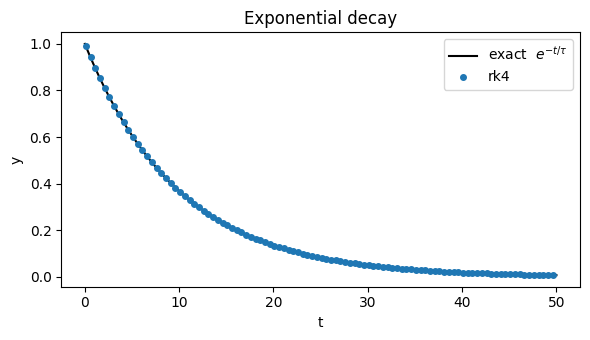

max abs error (rk4): 2.1823778006968553e-07


In [3]:
def integrate(model, solver_name, dt=0.1, t_end=50.0):
    brainstate.nn.init_all_states(model)
    step = braincell.quad.get_integrator(solver_name)
    n = int(t_end / dt)
    ts, ys = [], []
    with brainstate.environ.context(dt=dt):
        for i in range(n):
            with brainstate.environ.context(t=i * dt):
                step(model)
            ts.append((i + 1) * dt)
            ys.append(float(model.y.value[0]))
    return np.array(ts), np.array(ys)

t, y_rk4 = integrate(Decay(tau=10.0), "rk4")
t_exact = np.linspace(0, t[-1], 400)
y_exact = np.exp(-t_exact / 10.0)

plt.figure(figsize=(6, 3.5))
plt.plot(t_exact, y_exact, "k-", label="exact  $e^{-t/\\tau}$")
plt.plot(t[::5], y_rk4[::5], "o", ms=4, label="rk4")
plt.xlabel("t"); plt.ylabel("y"); plt.legend(); plt.title("Exponential decay")
plt.tight_layout(); plt.show()

print("max abs error (rk4):", np.max(np.abs(y_rk4 - np.exp(-t / 10.0))))

The Runge-Kutta solution sits right on top of the analytic curve — the
error is at the level of floating-point noise for this smooth, well-conditioned
problem.

## Worked example 2 — a two-state system

A module can own several `DiffEqState`s. Here is an undamped harmonic
oscillator,

$$\frac{dx}{dt} = v, \qquad \frac{dv}{dt} = -\omega^2 x,$$

which traces $x(t) = \cos(\omega t)$ for $x(0)=1,\ v(0)=0$. Each variable is its
own `DiffEqState`, and `compute_derivative` fills both in one pass.

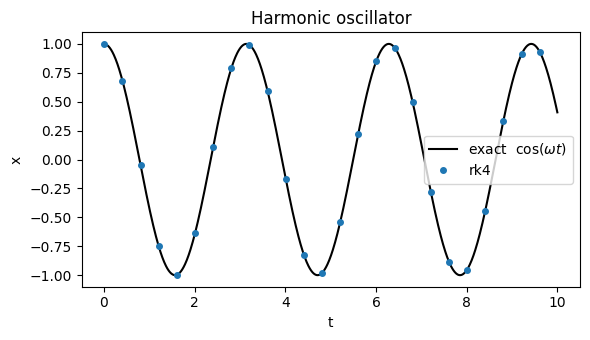

In [4]:
class Oscillator(brainstate.nn.Dynamics, DiffEqModule):
    def __init__(self, omega=1.0):
        super().__init__(in_size=1)
        self.omega = omega

    def init_state(self, *args):
        self.x = DiffEqState(jnp.ones(1))   # position, x(0) = 1
        self.v = DiffEqState(jnp.zeros(1))  # velocity, v(0) = 0

    def compute_derivative(self, *args):
        self.x.derivative = self.v.value
        self.v.derivative = -(self.omega ** 2) * self.x.value


osc = Oscillator(omega=2.0)
brainstate.nn.init_all_states(osc)
step = braincell.quad.get_integrator("rk4")

dt, n = 0.01, 1000
ts, xs = [], []
with brainstate.environ.context(dt=dt):
    for i in range(n):
        with brainstate.environ.context(t=i * dt):
            step(osc)
        ts.append((i + 1) * dt)
        xs.append(float(osc.x.value[0]))
ts, xs = np.array(ts), np.array(xs)

plt.figure(figsize=(6, 3.5))
plt.plot(ts, np.cos(2.0 * ts), "k-", label=r"exact  $\cos(\omega t)$")
plt.plot(ts[::40], xs[::40], "o", ms=4, label="rk4")
plt.xlabel("t"); plt.ylabel("x"); plt.legend(); plt.title("Harmonic oscillator")
plt.tight_layout(); plt.show()

Both `DiffEqState`s are advanced together by the same solver step — you
never integrate them by hand. That is the payoff of the protocol: you write the
right-hand side, and `braincell.quad` does the stepping.

## Where to go next

- [Choosing and Using Solvers](solvers) — the full solver catalog, how to pick
  one for stiff neural dynamics, and the high-level `solver=` shortcut.
- [Advanced Integration](advanced) — per-subsystem solvers, the stochastic
  `diffusion` slot, and registering your own integrator.